In [1]:
import os, sys
sys.path.append('../')

from pathlib import Path

# 创建输出目录
OUTPUT_DIR = Path('model_report')
OUTPUT_DIR.mkdir(exist_ok=True)
print(f"输出目录: {OUTPUT_DIR.resolve()}")

输出目录: /Users/lubberit/Desktop/workspace/hscredit/examples/model_report


# 12 完整建模工作流演示

本 Notebook 演示完整的风控建模流程，包括：
1. 数据加载与探索
2. 特征工程
3. 特征筛选
4. 模型训练
5. 模型评估
6. 生成模型报告

**数据说明**: 基于 `hscredit_yyp.xlsx`，目标变量为 `MOB1 > 3`

In [2]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from datetime import datetime

from hscredit import init_setting
from hscredit.core import metrics, viz

init_setting()

# 加载数据
df = pd.read_excel('hscredit_yyp.xlsx')

# 构造目标变量
df['target'] = (df['MOB1'] > 3).astype(int)

print("=" * 50)
print("数据加载完成")
print("=" * 50)
print(f"样本数: {len(df):,}")
print(f"特征数: {df.shape[1]}")
print(f"放款时间范围: {df['放款时间'].min()} ~ {df['放款时间'].max()}")
print(f"坏样本率: {df['target'].mean():.2%}")
print("=" * 50)

数据加载完成
样本数: 970
特征数: 19
放款时间范围: 2025-11-06 00:00:00 ~ 2026-02-25 00:00:00
坏样本率: 16.70%


## 第一步: 数据探索

In [3]:
# 选择建模特征
numeric_features = [
    '中智小牛分C3', '珊瑚92', '极光欺诈分6v1', '青云24', '占信V3',
    '轻花老客海纳子分V1', '天创小额网贷分', '衡枢鉴真分老客版'
]

# 移除缺失值过多的特征
df_model = df[numeric_features + ['target']].copy()
# df_model = df_model.dropna()

print(f"建模样本数: {len(df_model):,}")
print(f"建模特征数: {len(numeric_features)}")
print(f"\n特征描述统计:")
display(df_model[numeric_features].describe())

建模样本数: 970
建模特征数: 8

特征描述统计:


,中智小牛分C3,珊瑚92,极光欺诈分6v1,青云24,占信V3,轻花老客海纳子分V1,天创小额网贷分,衡枢鉴真分老客版
count,307.0000,264.0000,308.0000,970.0000,965.0000,938.0000,970.0000,970.0000
mean,635.9316,624.8636,0.3079,604.3258,573.6383,0.0653,710.3392,0.0946
std,91.2117,70.3443,0.2424,64.9345,62.6627,0.0566,52.5425,0.0524
min,464.0000,440.0000,0.0025,372.0000,349.0000,0.0090,497.0000,0.0095
25%,564.5000,589.5000,0.1028,561.2500,534.0000,0.0271,674.5000,0.0541
50%,629.0000,617.0000,0.2375,603.0000,578.0000,0.0455,712.0000,0.0838
75%,704.0000,653.0000,0.4688,647.0000,616.0000,0.0817,747.0000,0.1239
max,850.0000,850.0000,0.8808,850.0000,762.0000,0.3300,888.0000,0.3076


## 第二步: 数据划分

In [4]:
from sklearn.model_selection import train_test_split

X = df_model[numeric_features]
y = df_model['target']

# 划分训练集、测试集、OOT集
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.4, random_state=42, stratify=y
)
X_test, X_oot, y_test, y_oot = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print("数据集划分:")
print(f"  训练集: {len(X_train):,} ({len(X_train)/len(X):.1%})")
print(f"  测试集: {len(X_test):,} ({len(X_test)/len(X):.1%})")
print(f"  OOT集:  {len(X_oot):,} ({len(X_oot)/len(X):.1%})")
print(f"\n各集坏账率:")
print(f"  训练集: {y_train.mean():.2%}")
print(f"  测试集: {y_test.mean():.2%}")
print(f"  OOT集:  {y_oot.mean():.2%}")

数据集划分:
  训练集: 582 (60.0%)
  测试集: 194 (20.0%)
  OOT集:  194 (20.0%)

各集坏账率:
  训练集: 16.67%
  测试集: 17.01%
  OOT集:  16.49%


## 第三步: 特征筛选

In [5]:
from hscredit.core.selectors import IVSelector, CorrSelector, CompositeFeatureSelector

# IV筛选
iv_selector = IVSelector(threshold=0.02)
iv_selector.fit(X_train, y_train)

print("IV筛选结果:")
iv_df = pd.DataFrame({
    '特征': iv_selector.feature_names_in_,
    'IV': iv_selector.scores_
}).sort_values('IV', ascending=False)
display(iv_df)

# 保留高IV特征
high_iv_features = iv_df[iv_df['IV'] >= 0.02]['特征'].tolist()
print(f"\n保留特征 ({len(high_iv_features)}个): {high_iv_features}")

IV筛选结果:


,特征,IV
青云24,青云24,1.4767
占信V3,占信V3,1.4113
天创小额网贷分,天创小额网贷分,1.2424
珊瑚92,珊瑚92,1.1955
中智小牛分C3,中智小牛分C3,1.0899
极光欺诈分6v1,极光欺诈分6v1,1.0694
轻花老客海纳子分V1,轻花老客海纳子分V1,0.0020
衡枢鉴真分老客版,衡枢鉴真分老客版,0.0000



保留特征 (6个): ['青云24', '占信V3', '天创小额网贷分', '珊瑚92', '中智小牛分C3', '极光欺诈分6v1']


In [6]:
# 相关性筛选（基于IV，保留IV较高的特征）
corr_selector = CorrSelector(threshold=0.95, target='target')
corr_selector.fit(X_train[high_iv_features], y_train)

selected_features = corr_selector.selected_features_
print(f"相关性筛选后保留特征 ({len(selected_features)}个): {selected_features}")
if len(corr_selector.dropped_) > 0:
    print("\n剔除特征:")
    display(corr_selector.dropped_)

相关性筛选后保留特征 (6个): ['占信V3', '极光欺诈分6v1', '中智小牛分C3', '青云24', '珊瑚92', '天创小额网贷分']


### 评分卡模型训练

In [7]:
from hscredit import OptimalBinning, ScoreCard, LogisticRegression


binner = OptimalBinning(target='target', max_n_bins=5, min_bin_size=0.01, monotonic='auto_asc_desc', missing_separate=True)
binner.fit(df_model[selected_features + ['target']])

lr = LogisticRegression(target='target', C=1, max_iter=64)
lr.fit(binner.transform(df_model[selected_features + ['target']], metric='woe'))

scorecard = ScoreCard(binner=binner, lr_model=lr, target='target', base_score=600, pdo=50, step=50)
scorecard.fit(df_model[selected_features + ['target']], input_type='raw')

ScoreCard(base_score=600, binner=OptimalBinning(monotonic='auto_asc_desc'),
          lr_model=LogisticRegression(C=1, max_iter=64, target='target'),
          pdo=50, step=50)

In [8]:
lr.summary()

,Coef.,Std.Err,z,P>|z|,[0.025,0.975],VIF
const,-1.5989,0.0892,-17.9265,0.0000,-1.7737,-1.4241,1.0311
占信V3,0.8396,0.2438,3.4437,0.0006,0.3618,1.3175,1.0031
极光欺诈分6v1,0.6377,0.3660,1.7425,0.0814,-0.0796,1.3550,1.1995
中智小牛分C3,0.6751,0.3339,2.0221,0.0432,0.0207,1.3295,1.1716
青云24,0.7521,0.7013,1.0724,0.2835,-0.6225,2.1266,1.0047
珊瑚92,0.0018,0.7045,0.0026,0.9979,-1.3790,1.3826,1.2502
天创小额网贷分,0.0010,38.7470,0.0000,1.0000,-75.9432,75.9451,1.0069


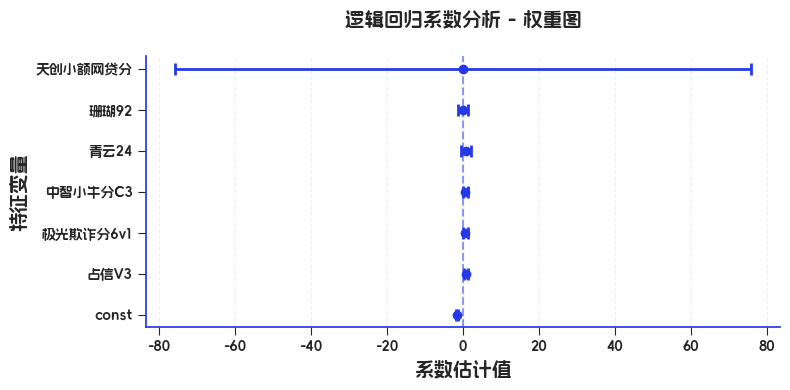

In [9]:
from hscredit.core.viz import plot_weights

plot_weights(lr, figsize=(8, 4));

In [10]:
df_model.loc[:0, selected_features]

,占信V3,极光欺诈分6v1,中智小牛分C3,青云24,珊瑚92,天创小额网贷分
0,NaN,NaN,NaN,656,NaN,630


In [11]:
scorecard.get_detailed_score(df_model.loc[:0])

样本信息                    占信V3                                 极光欺诈分6v1                         ...    青云24 珊瑚92                               天创小额网贷分                                                                                           评分分析
  样本索引        总分     截距分数  原始值             分箱    WOE        分数      原始值              分箱    WOE  ...      分数  原始值           分箱      WOE     分数      原始值           分箱 WOE      分数                                                                  评分原因
0    0 1846.8800 458.8700  NaN  [-inf, 460.4) 0.0561 1394.7700      NaN  [-inf, 0.3211) 0.0705  ... -1.3700  NaN  [-inf, 624) -23.0283 0.0100 630.0000  [-inf, 719) NaN -0.0000  占信V3提升1401.0分(当前1394.8分); 天创小额网贷分提升0.0分(当前-0.0分); 珊瑚92提升0.0分(当前0.0分)

[1 rows x 28 columns]

In [12]:
binner.get_bin_table('占信V3')

,分箱,分箱标签,样本总数,好样本数,坏样本数,样本占比,好样本占比,坏样本占比,坏样本率,分档WOE值,分档IV值,指标IV值,LIFT值,坏账改善,累积LIFT值,累积坏账改善,累积好样本数,累积坏样本数,分档KS值
0,0,"[-inf, 460.4)",49,33,16,0.0505,0.0408,0.0988,0.3265,0.8830,0.0511,0.2939,1.9552,0.0508,1.9552,0.0508,33,16,0.0579
1,1,"[460.4, 563.0)",331,269,62,0.3412,0.3329,0.3827,0.1873,0.1394,0.0069,0.2939,1.1216,0.0630,1.2290,0.1475,302,78,0.1077
2,2,"[563.0, 608.0)",286,234,52,0.2948,0.2896,0.3210,0.1818,0.1029,0.0032,0.2939,1.0887,0.0371,1.1688,0.3697,536,130,0.1391
3,3,"[608.0, 671.0)",245,216,29,0.2526,0.2673,0.1790,0.1184,-0.4010,0.0354,0.2939,0.7087,-0.0984,1.0450,0.6955,752,159,0.0508
4,4,"[671.0, +inf)",54,51,3,0.0557,0.0631,0.0185,0.0556,-1.2262,0.0547,0.2939,0.3326,-0.0393,1.0052,1.0000,803,162,0.0062
5,-1,missing,5,5,0,0.0052,0.0062,0.0000,0.0000,-23.0283,0.1425,0.2939,0.0000,-0.0052,1.0000,0.0000,808,162,0.0000


In [13]:
scorecard.scorecard_points()

,变量名称,变量含义,变量分箱,对应分数,WOE值
0,基础分,截距项（基准分数）,-,458.8735,NaN
1,占信V3,,"[-inf, 460.4)",-53.4838,0.8830
2,占信V3,,"[460.4, 563.0)",-8.4424,0.1394
3,占信V3,,"[563.0, 608.0)",-6.2317,0.1029
4,占信V3,,"[608.0, 671.0)",24.2885,-0.4010
5,占信V3,,"[671.0, +inf)",74.2706,-1.2262
6,占信V3,,缺失值,1394.7652,-23.0283
7,极光欺诈分6v1,,"[-inf, 0.3211)",24.2518,-0.5272
8,极光欺诈分6v1,,"[0.3211, 0.6971)",-8.8907,0.1933
9,极光欺诈分6v1,,"[0.6971, +inf)",-34.1313,0.7420


In [14]:
scorecard.score_odds_reference

,评分,理论Odds(坏好比),好客户:坏客户,理论逾期率,理论逾期率(%),对数Odds
0,850,0.0009,1120.0:1,0.0009,0.0892%,-7.0211
1,800,0.0018,560.0:1,0.0018,0.1783%,-6.3279
2,750,0.0036,280.0:1,0.0036,0.3559%,-5.6348
3,700,0.0071,140.0:1,0.0071,0.7092%,-4.9416
4,650,0.0143,70.0:1,0.0141,1.4085%,-4.2485
5,600,0.0286,35.0:1,0.0278,2.7778%,-3.5553
6,550,0.0571,17.5:1,0.0541,5.4054%,-2.8622
7,500,0.1143,8.8:1,0.1026,10.2564%,-2.1691
8,450,0.2286,4.4:1,0.1860,18.6047%,-1.4759
9,400,0.4571,2.2:1,0.3137,31.3725%,-0.7828


In [15]:
scorecard.lr_model.summary()

,Coef.,Std.Err,z,P>|z|,[0.025,0.975],VIF
const,-1.5989,0.0892,-17.9265,0.0000,-1.7737,-1.4241,1.0311
占信V3,0.8396,0.2438,3.4437,0.0006,0.3618,1.3175,1.0031
极光欺诈分6v1,0.6377,0.3660,1.7425,0.0814,-0.0796,1.3550,1.1995
中智小牛分C3,0.6751,0.3339,2.0221,0.0432,0.0207,1.3295,1.1716
青云24,0.7521,0.7013,1.0724,0.2835,-0.6225,2.1266,1.0047
珊瑚92,0.0018,0.7045,0.0026,0.9979,-1.3790,1.3826,1.2502
天创小额网贷分,0.0010,38.7470,0.0000,1.0000,-75.9432,75.9451,1.0069


In [16]:
scorecard.score_to_bad_rate_table(scorecard.predict(df_model[selected_features]), df_model['target'])

,评分区间,样本数,坏样本数,坏样本率,好样本数,Odds,累计好样本占比,累计坏样本占比,KS
0,"(316.49690000000004, 439.6679]",97,32,32.99%,65,2.03,0.0804,0.1975,0.1171
1,"(439.6679, 443.6735]",139,27,19.42%,112,4.15,0.2191,0.3642,0.1451
2,"(443.6735, 443.6738]",102,20,19.61%,82,4.10,0.3205,0.4877,0.1671
3,"(443.6738, 445.8843]",112,24,21.43%,88,3.67,0.4295,0.6358,0.2063
4,"(445.8843, 445.8846]",76,12,15.79%,64,5.33,0.5087,0.7099,0.2012
5,"(445.8846, 468.308]",57,8,14.04%,49,6.12,0.5693,0.7593,0.1900
6,"(468.308, 476.4045]",106,16,15.09%,90,5.62,0.6807,0.8580,0.1773
7,"(476.4045, 498.5139]",87,12,13.79%,75,6.25,0.7735,0.9321,0.1586
8,"(498.5139, 526.3866]",97,4,4.12%,93,23.25,0.8886,0.9568,0.0682
9,"(526.3866, 1846.8815]",97,7,7.22%,90,12.86,1.0000,1.0000,0.0000


In [17]:
scorecard.get_score_reference_by_prob(prob_range=(0, 0.99), n_points=20)

,理论逾期率,理论逾期率(%),理论Odds,评分
0,0.0001,0.0100%,0.0001,1007.9100
1,0.0522,5.2200%,0.0551,552.6600
2,0.1043,10.4300%,0.1164,498.6500
3,0.1564,15.6400%,0.1854,465.1000
4,0.2085,20.8500%,0.2634,439.7600
5,0.2606,26.0600%,0.3524,418.7600
6,0.3127,31.2700%,0.4550,400.3400
7,0.3648,36.4800%,0.5743,383.5400
8,0.4169,41.6900%,0.7150,367.7400
9,0.4690,46.9000%,0.8832,352.4900


In [18]:
"""评分卡 Python 部署代码（自动生成）"""
import numpy as np
import pandas as pd


def calculate_score(row: dict) -> float:
    """计算单条样本的评分卡分数.

    :param row: 样本特征字典
    :return: 评分
    """
    score = 458.8735  # base_score

    # 占信V3
    val = row.get("占信V3")
    if val < 460.4:
        score += -53.4838
    elif val >= 460.4 and val < 563.0:
        score += -8.4424
    elif val >= 563.0 and val < 608.0:
        score += -6.2317
    elif val >= 608.0 and val < 671.0:
        score += 24.2885
    elif val >= 671.0:
        score += 74.2706
    elif val is None or (isinstance(val, float) and np.isnan(val)):
        score += 1394.7652

    # 极光欺诈分6v1
    val = row.get("极光欺诈分6v1")
    if val < 0.3211:
        score += 24.2518
    elif val >= 0.3211 and val < 0.6971:
        score += -8.8907
    elif val >= 0.6971:
        score += -34.1313
    elif val is None or (isinstance(val, float) and np.isnan(val)):
        score += -2.6652

    # 中智小牛分C3
    val = row.get("中智小牛分C3")
    if val < 495.3:
        score += -53.3832
    elif val >= 495.3 and val < 611.7:
        score += -7.1756
    elif val >= 611.7 and val < 686.0:
        score += 25.241
    elif val >= 686.0 and val < 753.5:
        score += 28.7462
    elif val >= 753.5:
        score += 35.4743
    elif val is None or (isinstance(val, float) and np.isnan(val)):
        score += -2.7325

    # 青云24
    val = row.get("青云24")
    if val < 446.0:
        score += 1281.1934
    elif val >= 446.0 and val < 481.5:
        score += 63.236
    elif val >= 481.5:
        score += -1.3691

    # 珊瑚92
    val = row.get("珊瑚92")
    if val < 624.0:
        score += -0.0408
    elif val >= 624.0:
        score += -0.0093
    elif val is None or (isinstance(val, float) and np.isnan(val)):
        score += 0.0093

    # 天创小额网贷分
    val = row.get("天创小额网贷分")
    if val < 719.0:
        score += -0.0001
    elif val >= 719.0:
        score += 0.0002

    return score


def batch_calculate_score(df: pd.DataFrame) -> pd.Series:
    """批量计算评分."""
    return df.apply(lambda row: calculate_score(row.to_dict()), axis=1)

In [19]:
print(scorecard.export_deployment_code(language='python'))

"""评分卡 Python 部署代码（自动生成）"""
import numpy as np
import pandas as pd


def calculate_score(row: dict) -> float:
    """计算单条样本的评分卡分数.

    :param row: 样本特征字典
    :return: 评分
    """
    score = 458.8735  # base_score

    # 占信V3
    val = row.get("占信V3")
    if val < 460.4:
        score += -53.4838
    elif val >= 460.4 and val < 563.0:
        score += -8.4424
    elif val >= 563.0 and val < 608.0:
        score += -6.2317
    elif val >= 608.0 and val < 671.0:
        score += 24.2885
    elif val >= 671.0:
        score += 74.2706
    elif pd.isna(val):
        score += 1394.7652
    else:
        score += 0.0

    # 极光欺诈分6v1
    val = row.get("极光欺诈分6v1")
    if val < 0.3211:
        score += 24.2518
    elif val >= 0.3211 and val < 0.6971:
        score += -8.8907
    elif val >= 0.6971:
        score += -34.1313
    elif pd.isna(val):
        score += -2.6652
    else:
        score += 0.0

    # 中智小牛分C3
    val = row.get("中智小牛分C3")
    if val < 495.3:
        score += -53.3832
    

In [20]:
scorecard.export_pmml()

Standard output is empty
Standard error:
Exception in thread "main" org.jpmml.sklearn.SkLearnException: This converter version does not know about Scikit-Learn version 1.5.2 artifacts. Please upgrade the converter to the latest version, or downgrade Scikit-Learn to version 1.4.1
	at sklearn.Step.checkSkLearnVersion(Step.java:45)
	at sklearn.Step.checkVersion(Step.java:35)
	at sklearn.Estimator.encode(Estimator.java:119)
	at sklearn2pmml.pipeline.PMMLPipeline.encodePMML(PMMLPipeline.java:121)
	at com.sklearn2pmml.Main.run(Main.java:80)
	at com.sklearn2pmml.Main.main(Main.java:65)



RuntimeError: The SkLearn2PMML application has failed. The Java executable should have printed more information about the failure into its standard output and/or standard error streams

In [21]:
from pypmml import Model

model = Model.load('scorecard.pmml')

pd.DataFrame(zip(
    scorecard.predict(df_model),
    model.predict(df_model[lr.feature_names_in_])['predicted_score']
)).assign(diff=lambda x: x[0] - x[1]).describe()

,0,1,diff
count,970.0000,970.0000,970.0000
mean,483.0104,483.0605,-0.0501
std,160.8141,160.9588,0.2048
min,316.4970,316.7000,-2.0840
25%,443.6738,443.6800,-0.0248
50%,445.8846,445.8900,-0.0062
75%,476.4048,476.4100,-0.0054
max,1846.8815,1846.8500,0.0885


In [22]:
pd.DataFrame(zip(scorecard.predict(df_model), batch_calculate_score(df_model))).assign(diff=lambda x: x[0] - x[1]).describe()

,0,1,diff
count,970.0000,970.0000,970.0000
mean,483.0104,483.0104,0.0000
std,160.8141,160.8141,0.0000
min,316.4970,316.4970,-0.0001
25%,443.6738,443.6738,-0.0000
50%,445.8846,445.8845,0.0000
75%,476.4048,476.4047,0.0001
max,1846.8815,1846.8814,0.0001


## 评分卡模型报告

基于上面训练好的 `scorecard` 生成评分卡模型报告，并分别查看训练集、测试集和 OOT 集的效果。

In [ ]:
from hscredit.report.model_report import auto_model_report, QuickModelReport

# 保存至 model_report 目录
scorecard_report_file = OUTPUT_DIR / 'scorecard_model_report.xlsx'

# =============================================================================
# auto_model_report 支持 3 种调用方式（sklearn / scorecardpipeline 风格均支持）
# =============================================================================

# 方式一: sklearn 风格 — 传入 X_train/y_train/X_test/y_test
scorecard_report = auto_model_report(
    scorecard,
    X_train=X_train[selected_features],
    y_train=y_train,
    X_test=X_test[selected_features],
    y_test=y_test,
    excel_path=str(scorecard_report_file),
    verbose=False,
    n_bins=8,
    bin_method='quantile',
    model_name='ScoreCard评分卡模型',
)

In [ ]:
# =============================================================================
# auto_model_report 方式二: datasets dict 风格 — 传入 {数据集名: (X, y)} 字典
# 支持 train / test / oot 等命名数据集，自动生成多集对比报告
# =============================================================================

scorecard_report_dict = auto_model_report(
    scorecard,
    datasets={
        "train": (X_train[selected_features], y_train),
        "test":  (X_test[selected_features],  y_test),
        "oot":   (X_oot[selected_features],   y_oot),
    },
    excel_path=str(OUTPUT_DIR / "scorecard_model_report_dict.xlsx"),
    verbose=False,
    n_bins=8,
    bin_method="quantile",
    model_name="ScoreCard评分卡模型 (dict)",
)

display(scorecard_report_dict.get_metrics())


In [ ]:
# =============================================================================
# auto_model_report 方式三: datasets list 风格 — 传入 [(X, y), (X, y), ...] 列表
# 列表顺序对应数据集 0, 1, 2... 简洁高效
# =============================================================================

scorecard_report_list = auto_model_report(
    scorecard,
    datasets=[
        (X_train[selected_features], y_train),
        (X_test[selected_features],  y_test),
        (X_oot[selected_features],   y_oot),
    ],
    excel_path=str(OUTPUT_DIR / "scorecard_model_report_list.xlsx"),
    verbose=False,
    n_bins=8,
    bin_method="quantile",
    model_name="ScoreCard评分卡模型 (list)",
)

display(scorecard_report_list.get_metrics())


In [ ]:
# 查看核心指标
display(scorecard_report.get_metrics())

# 查看特征重要性
display(scorecard_report.get_feature_importance(top_n=10))

# 查看训练集分箱表
display(scorecard_report.get_bin_table('train', method='quantile', max_n_bins=8))

# 查看测试集分箱表
display(scorecard_report.get_bin_table('test', method='quantile', max_n_bins=8))

,统计项,训练集,测试集
0,KS,0.2660,0.2296
1,AUC,0.6607,0.5663
2,样本数,582,194.0000
3,坏样本率,0.1667,0.1701
4,PSI,\,0.0002


,特征重要性,IV,KS,PSI
占信V3,0.2888,0.2664,0.2124,0.0007
青云24,0.2587,0.0504,0.1464,0.0021
中智小牛分C3,0.2322,1.7436,0.0639,0.0643
极光欺诈分6v1,0.2193,5.7602,0.1010,0.0692
珊瑚92,0.0006,4.9695,0.0495,0.0143
天创小额网贷分,0.0003,0.0437,0.1196,0.0290


,指标名称,指标含义,分箱标签,样本总数,好样本数,坏样本数,样本占比,好样本占比,坏样本占比,坏样本率,分档WOE值,分档IV值,指标IV值,LIFT值,坏账改善,累积LIFT值,累积坏账改善,累积好样本数,累积坏样本数,分档KS值
0,__score__,模型评分,"[-inf, 398.6324)",30,20,10,0.0515,0.0412,0.1031,0.3333,0.9163,0.0567,1.8235,2.0000,0.0543,2.0000,0.0543,20,10,0.0619
1,__score__,模型评分,"[398.6324, 443.6735)",114,86,28,0.1959,0.1773,0.2887,0.2456,0.4873,0.0543,1.8235,1.4737,0.1154,1.5833,0.1918,106,38,0.1732
2,__score__,模型评分,"[443.6735, 445.8843)",133,104,29,0.2285,0.2144,0.2990,0.2180,0.3323,0.0281,1.8235,1.3083,0.0913,1.4513,0.4098,210,67,0.2577
3,__score__,模型评分,"[445.8843, 445.8846)",47,43,4,0.0808,0.0887,0.0412,0.0851,-0.7655,0.0363,1.8235,0.5106,-0.0430,1.3148,0.3953,253,71,0.2103
4,__score__,模型评分,"[445.8846, 476.4048)",134,115,19,0.2302,0.2371,0.1959,0.1418,-0.1911,0.0079,1.8235,0.8507,-0.0446,1.1790,0.6613,368,90,0.1691
5,__score__,模型评分,"[476.4048, 501.6393)",30,27,3,0.0515,0.0557,0.0309,0.1000,-0.5878,0.0145,1.8235,0.6000,-0.0217,1.1434,0.7447,395,93,0.1443
6,__score__,模型评分,"[501.6393, 541.4549)",64,60,4,0.1100,0.1237,0.0412,0.0625,-1.0986,0.0906,1.8235,0.3750,-0.0772,1.0543,1.0000,455,97,0.0619
7,__score__,模型评分,"[541.4549, +inf)",30,30,0,0.0515,0.0619,0.0000,0.0000,-24.8176,1.5351,1.8235,0.0000,-0.0543,1.0000,0.0000,485,97,0.0000
8,__score__,模型评分,合计,582,485,97,1.0000,1.0000,1.0000,0.1667,0.0000,0.0000,1.8235,1.0000,1.0000,1.0000,1.0000,2292,563,0.2577


,指标名称,指标含义,分箱标签,样本总数,好样本数,坏样本数,样本占比,好样本占比,坏样本占比,坏样本率,分档WOE值,分档IV值,指标IV值,LIFT值,坏账改善,累积LIFT值,累积坏账改善,累积好样本数,累积坏样本数,分档KS值
0,__score__,模型评分,"[-inf, 445.8843)",91,75,16,0.4691,0.4658,0.4848,0.1758,0.0400,0.0008,6.4963,1.0336,0.0297,1.0336,0.0297,75,16,0.0190
1,__score__,模型评分,"[445.8843, 465.7175)",19,10,9,0.0979,0.0621,0.2727,0.4737,1.4795,0.3116,6.4963,2.7847,0.1938,1.3361,0.4401,85,25,0.2296
2,__score__,模型评分,"[465.7175, 472.8617)",12,12,0,0.0619,0.0745,0.0000,0.0000,-23.9259,1.7833,6.4963,0.0000,-0.0659,1.2047,0.3468,97,25,0.1551
3,__score__,模型评分,"[472.8617, 476.4045)",10,9,1,0.0515,0.0559,0.0303,0.1000,-0.6123,0.0157,6.4963,0.5879,-0.0224,1.1579,0.3363,106,26,0.1295
4,__score__,模型评分,"[476.4045, 476.4048)",19,16,3,0.0979,0.0994,0.0909,0.1579,-0.0891,0.0008,6.4963,0.9282,-0.0078,1.1290,0.4531,122,29,0.1210
5,__score__,模型评分,"[476.4048, 501.6393)",16,16,0,0.0825,0.0994,0.0000,0.0000,-24.2135,2.4063,6.4963,0.0000,-0.0899,1.0209,0.1291,138,29,0.0216
6,__score__,模型评分,"[501.6393, 534.7503)",13,13,0,0.0670,0.0807,0.0000,0.0000,-24.0059,1.9384,6.4963,0.0000,-0.0718,0.9471,-0.6797,151,29,0.0591
7,__score__,模型评分,"[534.7503, +inf)",14,10,4,0.0722,0.0621,0.1212,0.2857,0.6686,0.0395,6.4963,1.6797,0.0529,1.0000,0.0000,161,33,0.0000
8,__score__,模型评分,合计,194,161,33,1.0000,1.0000,1.0000,0.1701,0.0000,0.0000,6.4963,1.0000,1.0000,1.0000,1.0000,935,212,0.2296


In [ ]:
# =============================================================================
# QuickModelReport 支持两种调用方式
# =============================================================================

# 方式一: sklearn 风格 — 传入 X_train/y_train/X_test/y_test
scorecard_qr_sklearn = QuickModelReport(
    scorecard,
    X_train[selected_features], y_train,
    X_oot[selected_features],   y_oot,
)

# 方式二: datasets dict 风格 — 传入 {数据集名: (X, y)} 字典
scorecard_qr_dict = QuickModelReport(
    scorecard,
    datasets={
        "train": (X_train[selected_features], y_train),
        "test":  (X_test[selected_features],  y_test),
        "oot":   (X_oot[selected_features],   y_oot),
    }
)

# 方式三: datasets list 风格 — 传入 [(X, y), (X, y), ...] 列表
scorecard_qr_list = QuickModelReport(
    scorecard,
    datasets=[
        (X_train[selected_features], y_train),
        (X_test[selected_features],  y_test),
        (X_oot[selected_features],   y_oot),
    ]
)

# 查看核心指标（train vs test vs oot）
display(scorecard_qr_dict.get_metrics())


,统计项,训练集,测试集
0,KS,0.2660,0.2909
1,AUC,0.6607,0.6641
2,样本数,582,194.0000
3,坏样本率,0.1667,0.1649
4,PSI,\,0.0028


,指标名称,指标含义,分箱标签,样本总数,好样本数,坏样本数,样本占比,好样本占比,坏样本占比,坏样本率,分档WOE值,分档IV值,指标IV值,LIFT值,坏账改善,累积LIFT值,累积坏账改善,累积好样本数,累积坏样本数,分档KS值
0,__score__,模型评分,"[-inf, 407.7642)",14,9,5,0.0722,0.0556,0.1562,0.3571,1.0341,0.1041,2.2153,2.1652,0.0906,2.1652,0.0906,9,5,0.1007
1,__score__,模型评分,"[407.7642, 443.6735)",31,24,7,0.1598,0.1481,0.2188,0.2258,0.3897,0.0275,2.2153,1.3690,0.0702,1.6167,0.1862,33,12,0.1713
2,__score__,模型评分,"[443.6735, 445.8843)",37,29,8,0.1907,0.1790,0.2500,0.2162,0.3340,0.0237,2.2153,1.3108,0.0732,1.4787,0.3504,62,20,0.2423
3,__score__,模型评分,"[445.8843, 475.6364)",43,37,6,0.2216,0.2284,0.1875,0.1395,-0.1973,0.0081,2.2153,0.8459,-0.0439,1.2610,0.4728,99,26,0.2014
4,__score__,模型评分,"[475.6364, 476.4045)",12,9,3,0.0619,0.0556,0.0938,0.2500,0.5232,0.0200,2.2153,1.5156,0.0340,1.2833,0.6809,108,29,0.2396
5,__score__,模型评分,"[476.4045, 476.4048)",15,13,2,0.0773,0.0802,0.0625,0.1333,-0.2499,0.0044,2.2153,0.8083,-0.0161,1.2364,0.8557,121,31,0.2218
6,__score__,模型评分,"[476.4048, 534.8005)",30,29,1,0.1546,0.1790,0.0312,0.0333,-1.7454,0.2579,2.2153,0.2021,-0.1460,1.0659,1.0000,150,32,0.0741
7,__score__,模型评分,"[534.8005, +inf)",12,12,0,0.0619,0.0741,0.0000,0.0000,-23.8889,1.7695,2.2153,0.0000,-0.0659,1.0000,0.0000,162,32,0.0000
8,__score__,模型评分,合计,194,162,32,1.0000,1.0000,1.0000,0.1649,0.0000,0.0000,2.2153,1.0000,1.0000,1.0000,1.0000,744,187,0.2423


## 第五步: Pipeline 建模工作流

使用 sklearn Pipeline 将分箱、编码、模型串联为可复用的建模流程。


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from hscredit.core.binning import OptimalBinning as BinningTransformer
from hscredit.core.encoders import WOEEncoder

# Step 1: 分箱器（基于训练集拟合）
bin_transformer = BinningTransformer(
    max_n_bins=5,
    min_bin_size=0.01,
    monotonic='auto_asc_desc',
    missing_value='separate'
)
bin_transformer.fit(X_train[selected_features], y_train)

# Step 2: WOE 编码器
woe_encoder = WOEEncoder()

# Step 3: 逻辑回归
lr_pipeline = LogisticRegression(C=1, max_iter=100, random_state=42)

# 构建 Pipeline
scorecard_pipeline = Pipeline([
    ('binning', bin_transformer),
    ('woe', woe_encoder),
    ('classifier', lr_pipeline),
])

# 训练 Pipeline
scorecard_pipeline.fit(X_train[selected_features], y_train)

# 预测概率
y_prob_train = scorecard_pipeline.predict_proba(X_train[selected_features])[:, 1]
y_prob_test = scorecard_pipeline.predict_proba(X_test[selected_features])[:, 1]

from hscredit.core.metrics import ks, auc

print("=== Pipeline 模型效果 ===")
print(f"训练集 KS: {ks(y_train, y_prob_train):.4f}, AUC: {auc(y_train, y_prob_train):.4f}")
print(f"测试集 KS: {ks(y_test, y_prob_test):.4f}, AUC: {auc(y_test, y_prob_test):.4f}")

# Pipeline 等价于: bin_transformer -> woe_encoder -> classifier
X_binned_train = bin_transformer.transform(X_train[selected_features])
X_woe_train = woe_encoder.fit_transform(X_binned_train, y_train)
y_prob_manual = lr_pipeline.predict_proba(X_woe_train)[:, 1]
print(f"\nPipeline vs 手工等价: diff max = {abs(y_prob_train - y_prob_manual).max():.6f}")


## 第六步: 带金额口径的模型报告

`auto_model_report` 支持传入 `amount_col` 参数，在报告中同时展示订单口径和金额口径的分析结果。


In [ ]:
# 准备金额字段（hscredit_yyp.xlsx 中为 放款金额）
df_full = df.copy()
df_full['target'] = (df_full['MOB1'] > 3).astype(int)

# 重新划分，确保金额字段对齐
X_train_full, X_temp, y_train_full, y_temp = train_test_split(
    df_full[selected_features + ['放款金额']], df_full['target'],
    test_size=0.4, random_state=42, stratify=df_full['target']
)
X_test_full, X_oot_full, y_test_full, y_oot_full = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

amount_col = '放款金额'
X_train_feat = X_train_full[selected_features]
X_test_feat = X_test_full[selected_features]
X_oot_feat = X_oot_full[selected_features]

# 使用 QuickModelReport 生成三集报告（含金额口径）
report_amt = QuickModelReport(
    scorecard,
    X_train_feat, y_train_full,
    X_test_feat, y_test_full,
)

# 添加 OOT 集
report_amt.add_dataset('oot', 'OOT集', X_oot_feat, y_oot_full)

# 生成带金额口径的 Excel 报告
excel_with_amount = OUTPUT_DIR / 'scorecard_report_with_amount.xlsx'
report_amt.to_excel(
    excel_path=str(excel_with_amount),
    n_bins=8,
    bin_method='quantile',
    amount_col=amount_col,
    verbose=False,
)

print(f"金额口径报告已保存: {excel_with_amount}")

# 查看金额口径的特征分箱表（对比订单 vs 金额）
feat_name = '占信V3'
print(f"\n=== {feat_name} 特征分箱对比 ===")

print("\n【订单口径】")
display(report_amt.get_feature_bin_table(feat_name, 'train', method='quantile', max_n_bins=5))

print("【金额口径】")
display(report_amt.get_feature_bin_table(feat_name, 'train', method='quantile', max_n_bins=5, amount_col=amount_col))


## 第七步: 模型保存与加载

评分卡模型支持 pickle 序列化保存，支持分箱器、逻辑回归、评分卡整体保存与加载。


In [ ]:
import pickle

# 保存评分卡模型
model_path = OUTPUT_DIR / 'scorecard_model.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(scorecard, f)

# 加载评分卡模型
with open(model_path, 'rb') as f:
    loaded_scorecard = pickle.load(f)

# 验证加载后预测一致
scores_original = scorecard.predict(df_model[selected_features])
scores_loaded = loaded_scorecard.predict(df_model[selected_features])
print(f"模型保存路径: {model_path}")
print(f"加载后预测最大差异: {abs(scores_original - scores_loaded).max():.6f}")

# 导出部署代码
deploy_path = OUTPUT_DIR / 'scorecard_deploy.py'
with open(deploy_path, 'w', encoding='utf-8') as f:
    f.write(scorecard.export_deployment_code(language='python'))

print(f"部署代码已导出: {deploy_path}")

# 导出 PMML
pmml_path = OUTPUT_DIR / 'scorecard.pmml'
scorecard.export_pmml(str(pmml_path))
print(f"PMML 文件已导出: {pmml_path}")


## 总结

本 Notebook 完整演示了 HSCredit 评分卡建模流程：

1. **数据探索** — 加载数据，构造目标变量，查看特征统计
2. **数据划分** — 训练集 / 测试集 / OOT 集分层抽样
3. **特征筛选** — IV 筛选 + 相关性筛选
4. **评分卡建模** — 最优分箱 + WOE 编码 + 逻辑回归 + 评分转换
5. **Pipeline 工作流** — sklearn Pipeline 串联分箱、编码、模型
6. **模型报告** — `auto_model_report` / `QuickModelReport` 支持订单口径 + 金额口径
7. **模型持久化** — pickle / PMML / Python 部署代码

**输出文件列表**（`examples/model_report/`）：


In [ ]:
import os
print(f"输出目录: {OUTPUT_DIR.resolve()}")
print("-" * 40)
files = sorted(OUTPUT_DIR.glob('*'))
for f in files:
    size = f.stat().st_size
    size_str = f'{size/1024:.1f} KB' if size > 1024 else f'{size} B'
    print(f'  {f.name:<45} {size_str}')
print("-" * 40)
print(f'共 {len(files)} 个文件')
